In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [3]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

# Data Cleaning

In [4]:
print("Missing Values: ")
df.isnull().sum()

Missing Values: 


,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [5]:
df.fillna(df.mean(), inplace=True)

In [6]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


# Model Training

In [7]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43)

In [10]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (354, 13)
Test Shape: (152, 13)


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("Predicted values: ", y_pred[:5])
print("Actual values: ", y_test[:5].values)

Predicted values:  [22.31226816 16.58329625 20.23367663 33.13259939 16.3980234 ]
Actual values:  [25.  23.2 20.5 31.6 17.6]


In [15]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_test, y_test)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

RMSE:  4.884904987512189
R2 Score:  0.7101159201309639


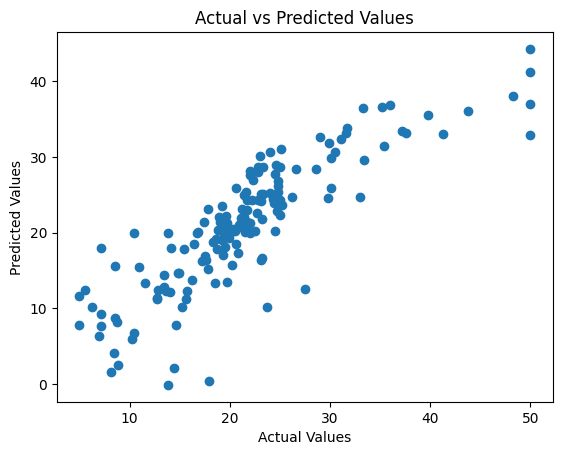

In [16]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

# Evaluation of unseen data

In [18]:
new_Data = pd.DataFrame([{
"CRIM": 0.06,
"ZN":	0.3,
"INDUS"	:0.1,
"CHAS"	:0.4,
"NOX"	:0.6,
"RM"	:0.1,
"AGE"	:0.8,
"DIS"	:0.9,
"RAD"	:0.1,
"TAX"	:10,
"PTRATIO"	:0.2,
"B"	:30,
"LSTAT":0.3
}])

In [20]:
prediction = model.predict(new_Data)

In [22]:
print("Predicted Price : ", prediction[0])

Predicted Price :  23.241618818253805
